In [ ]:
#FINAL CODE FOR DIABETES PREDICTION .

C:\Users\Anshika\anaconda3\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


First 5 rows of dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    in

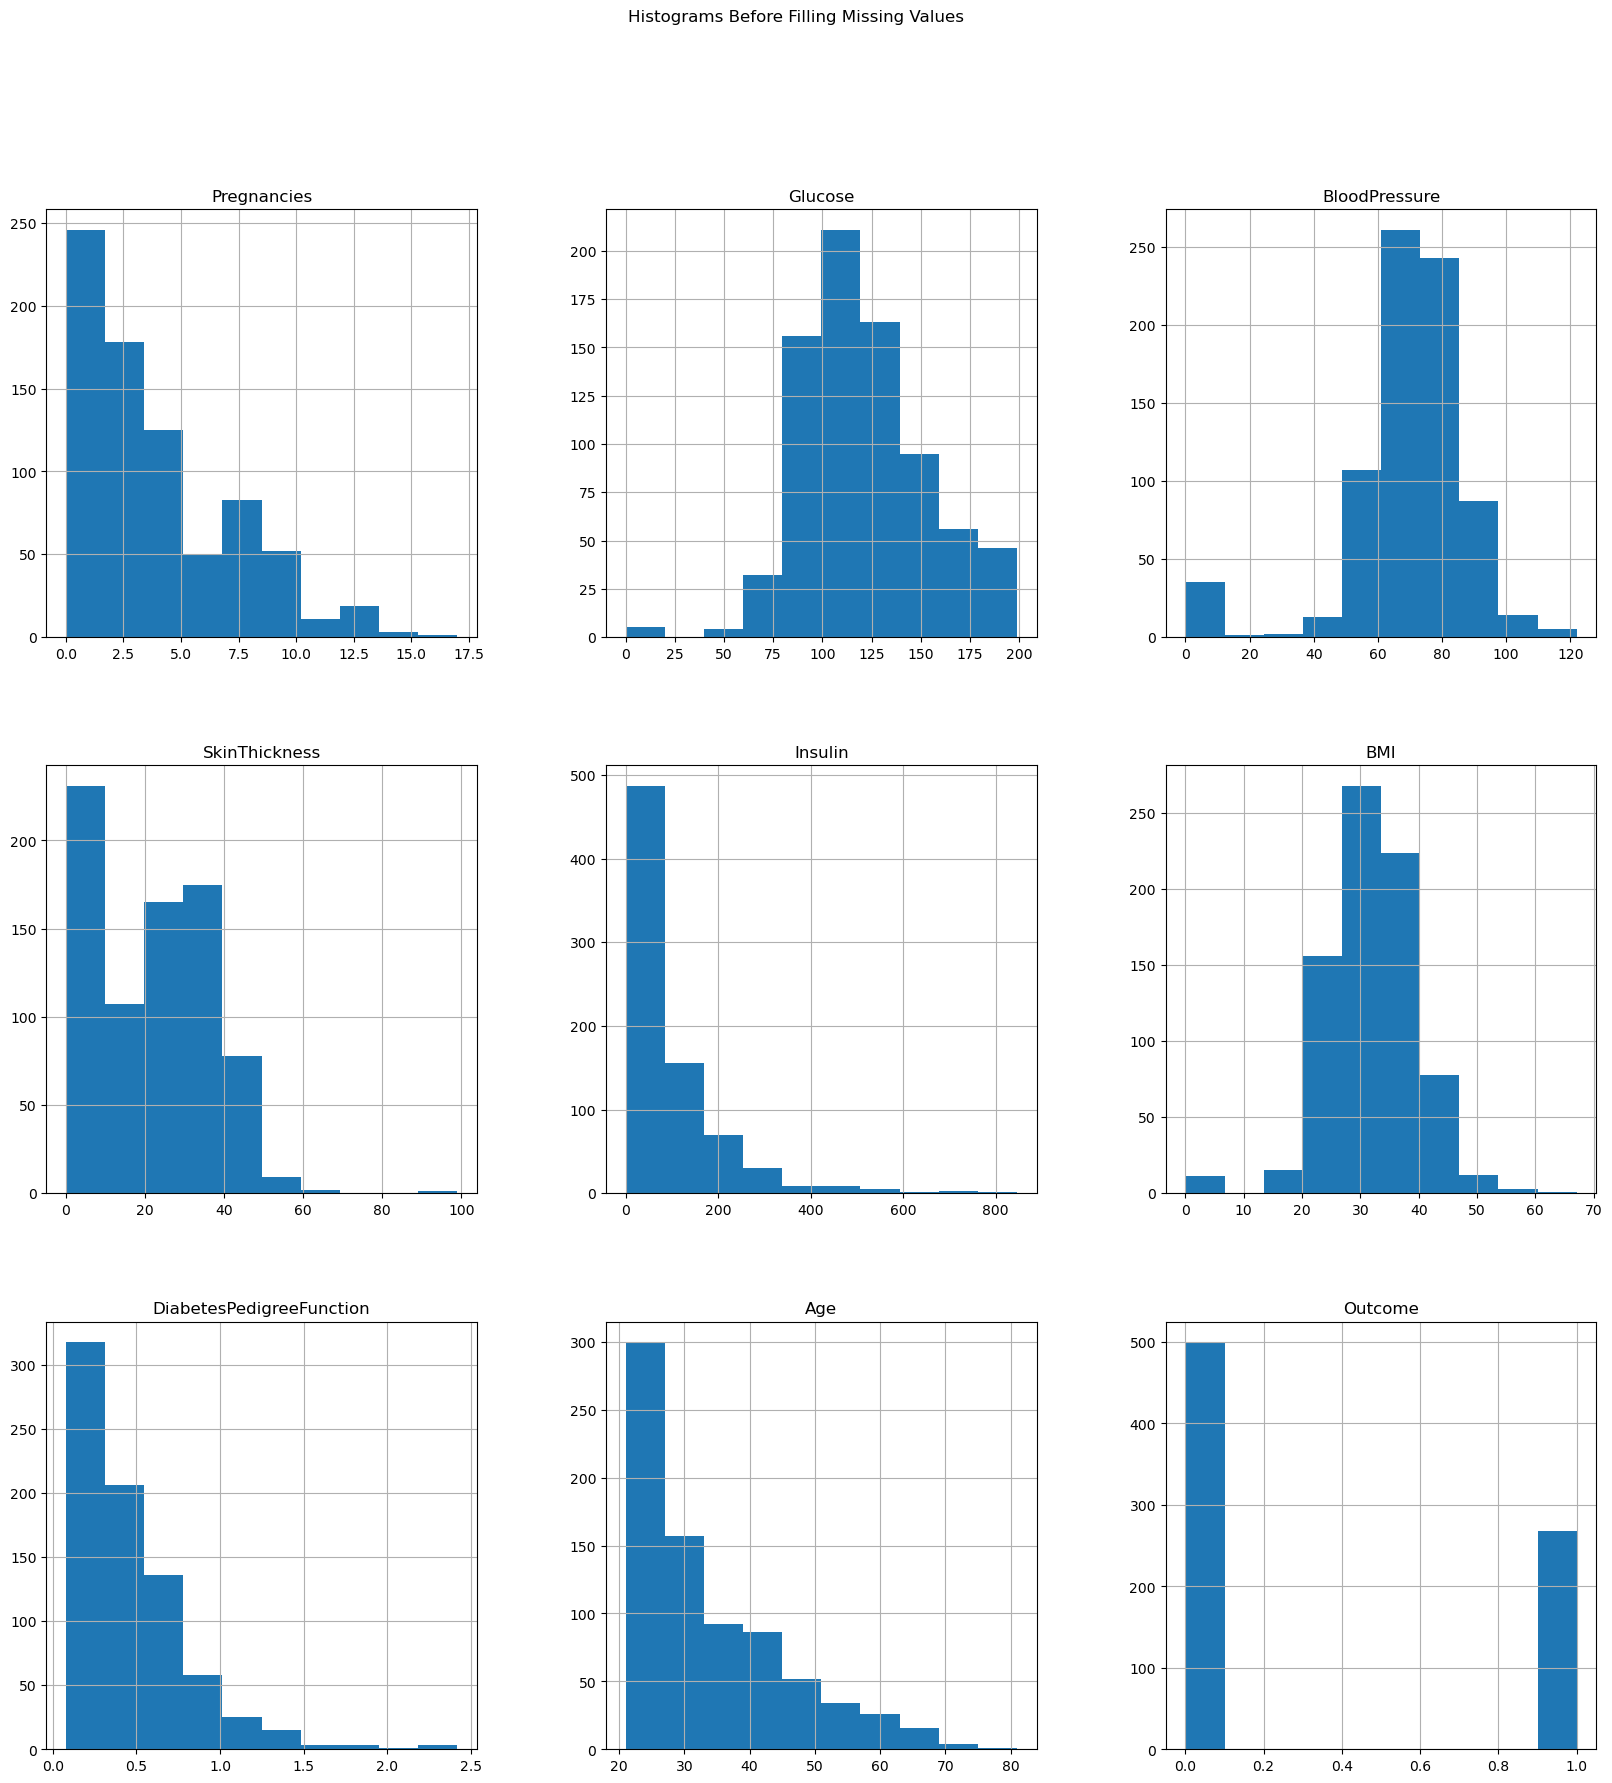

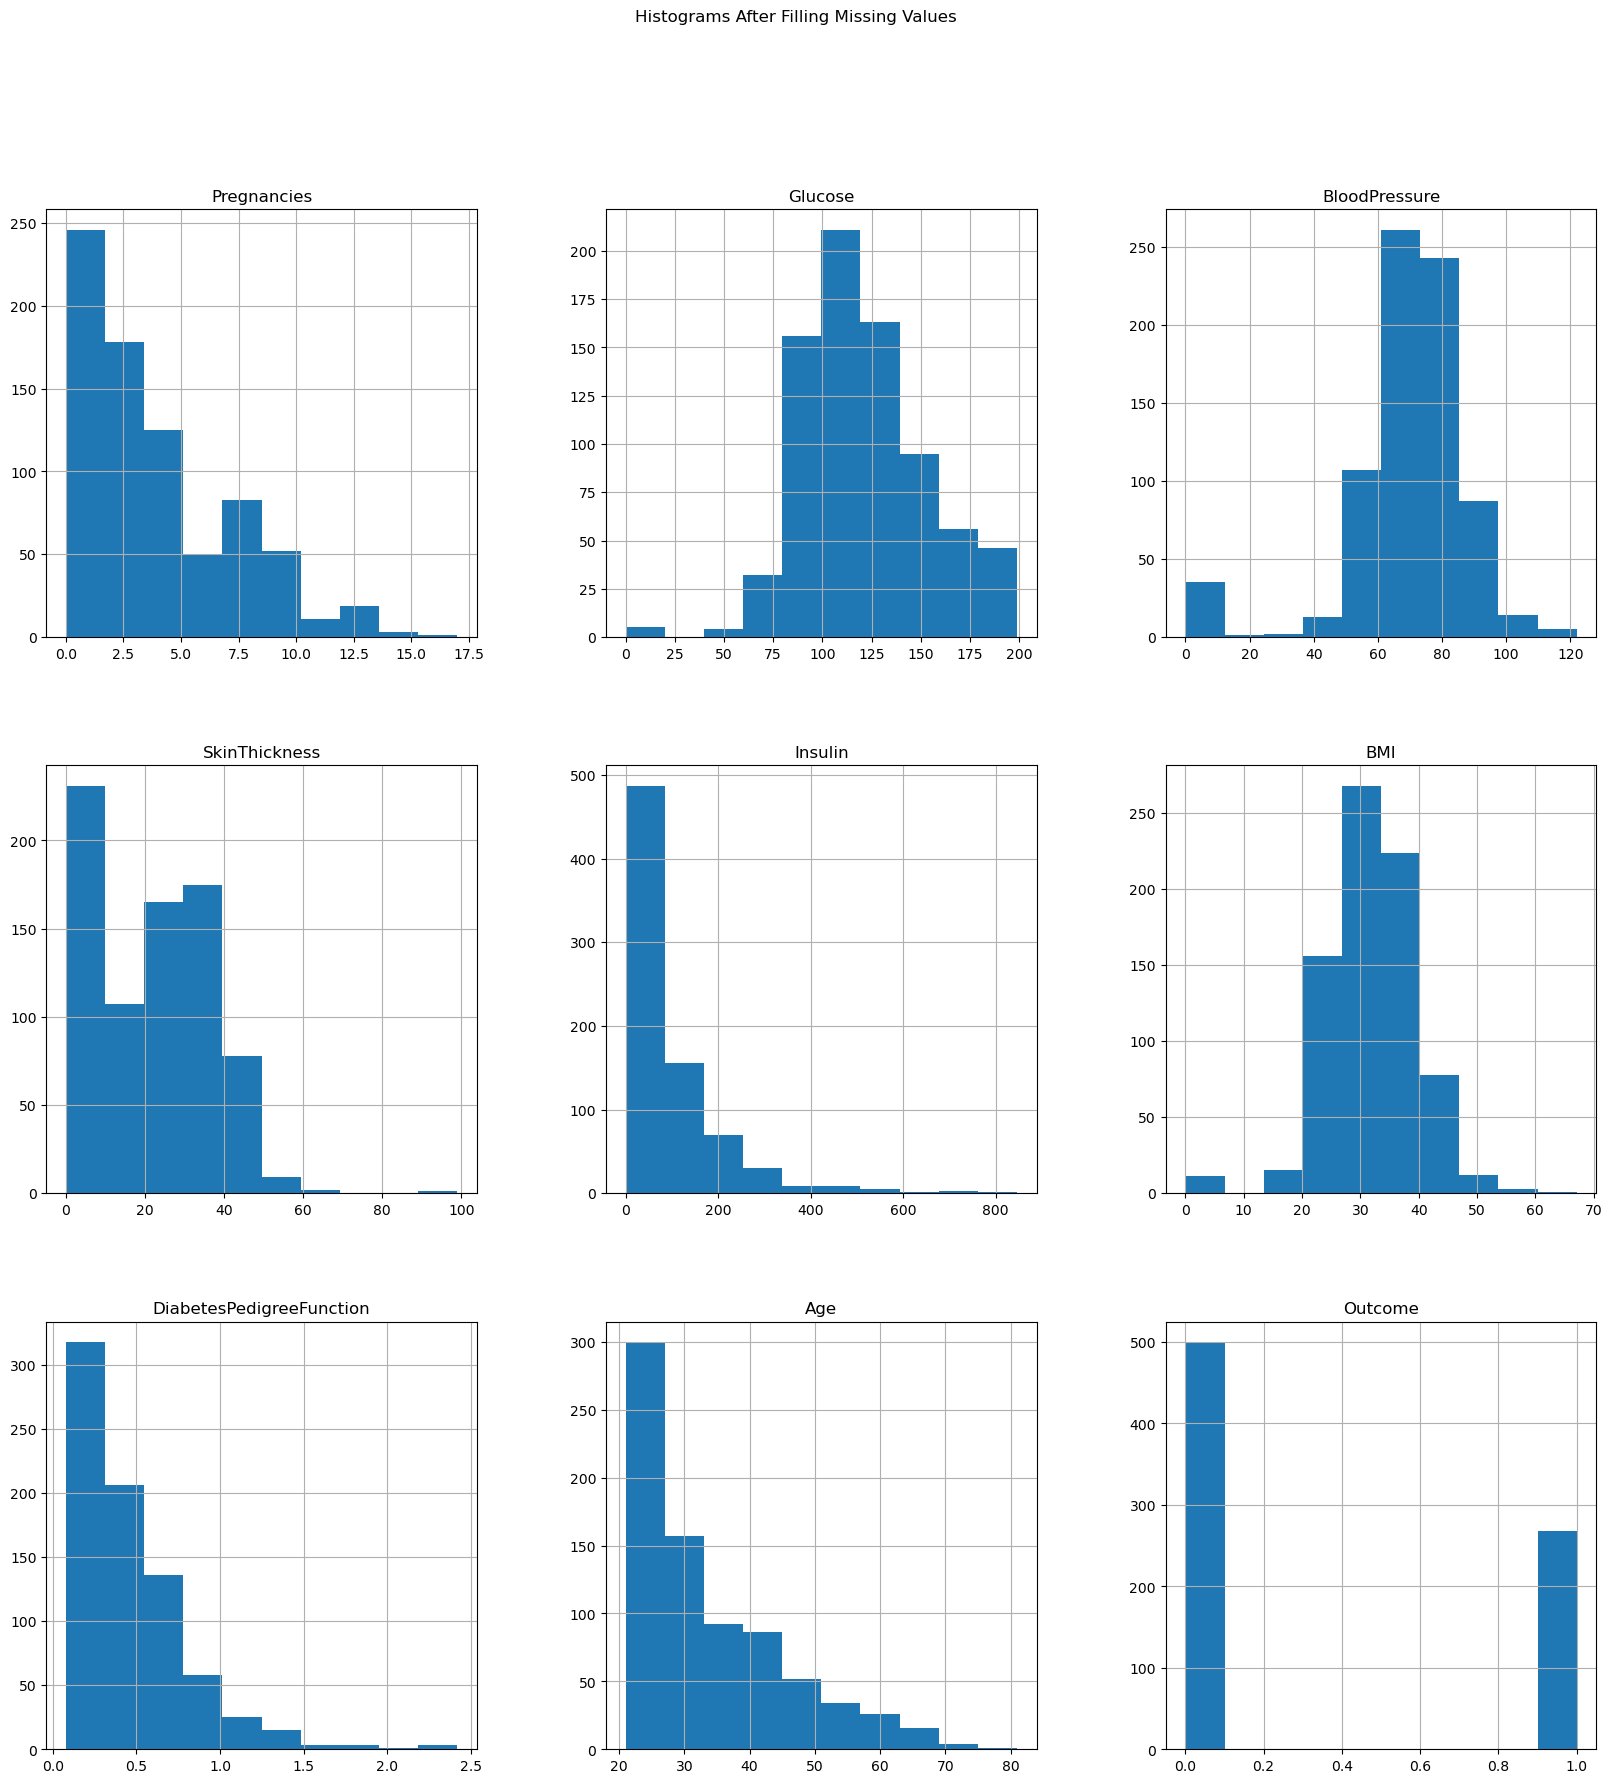


Outcome Class Distribution:
0    500
1    268
Name: Outcome, dtype: int64


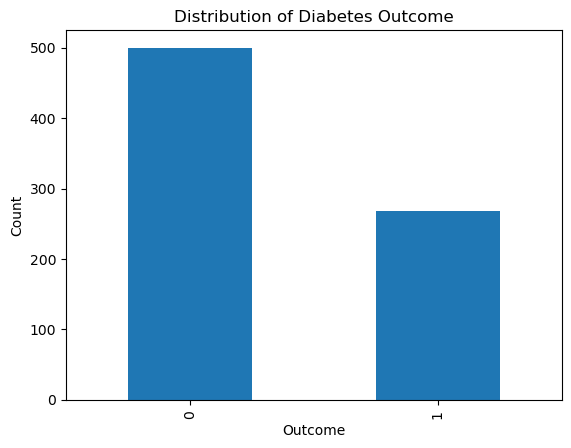

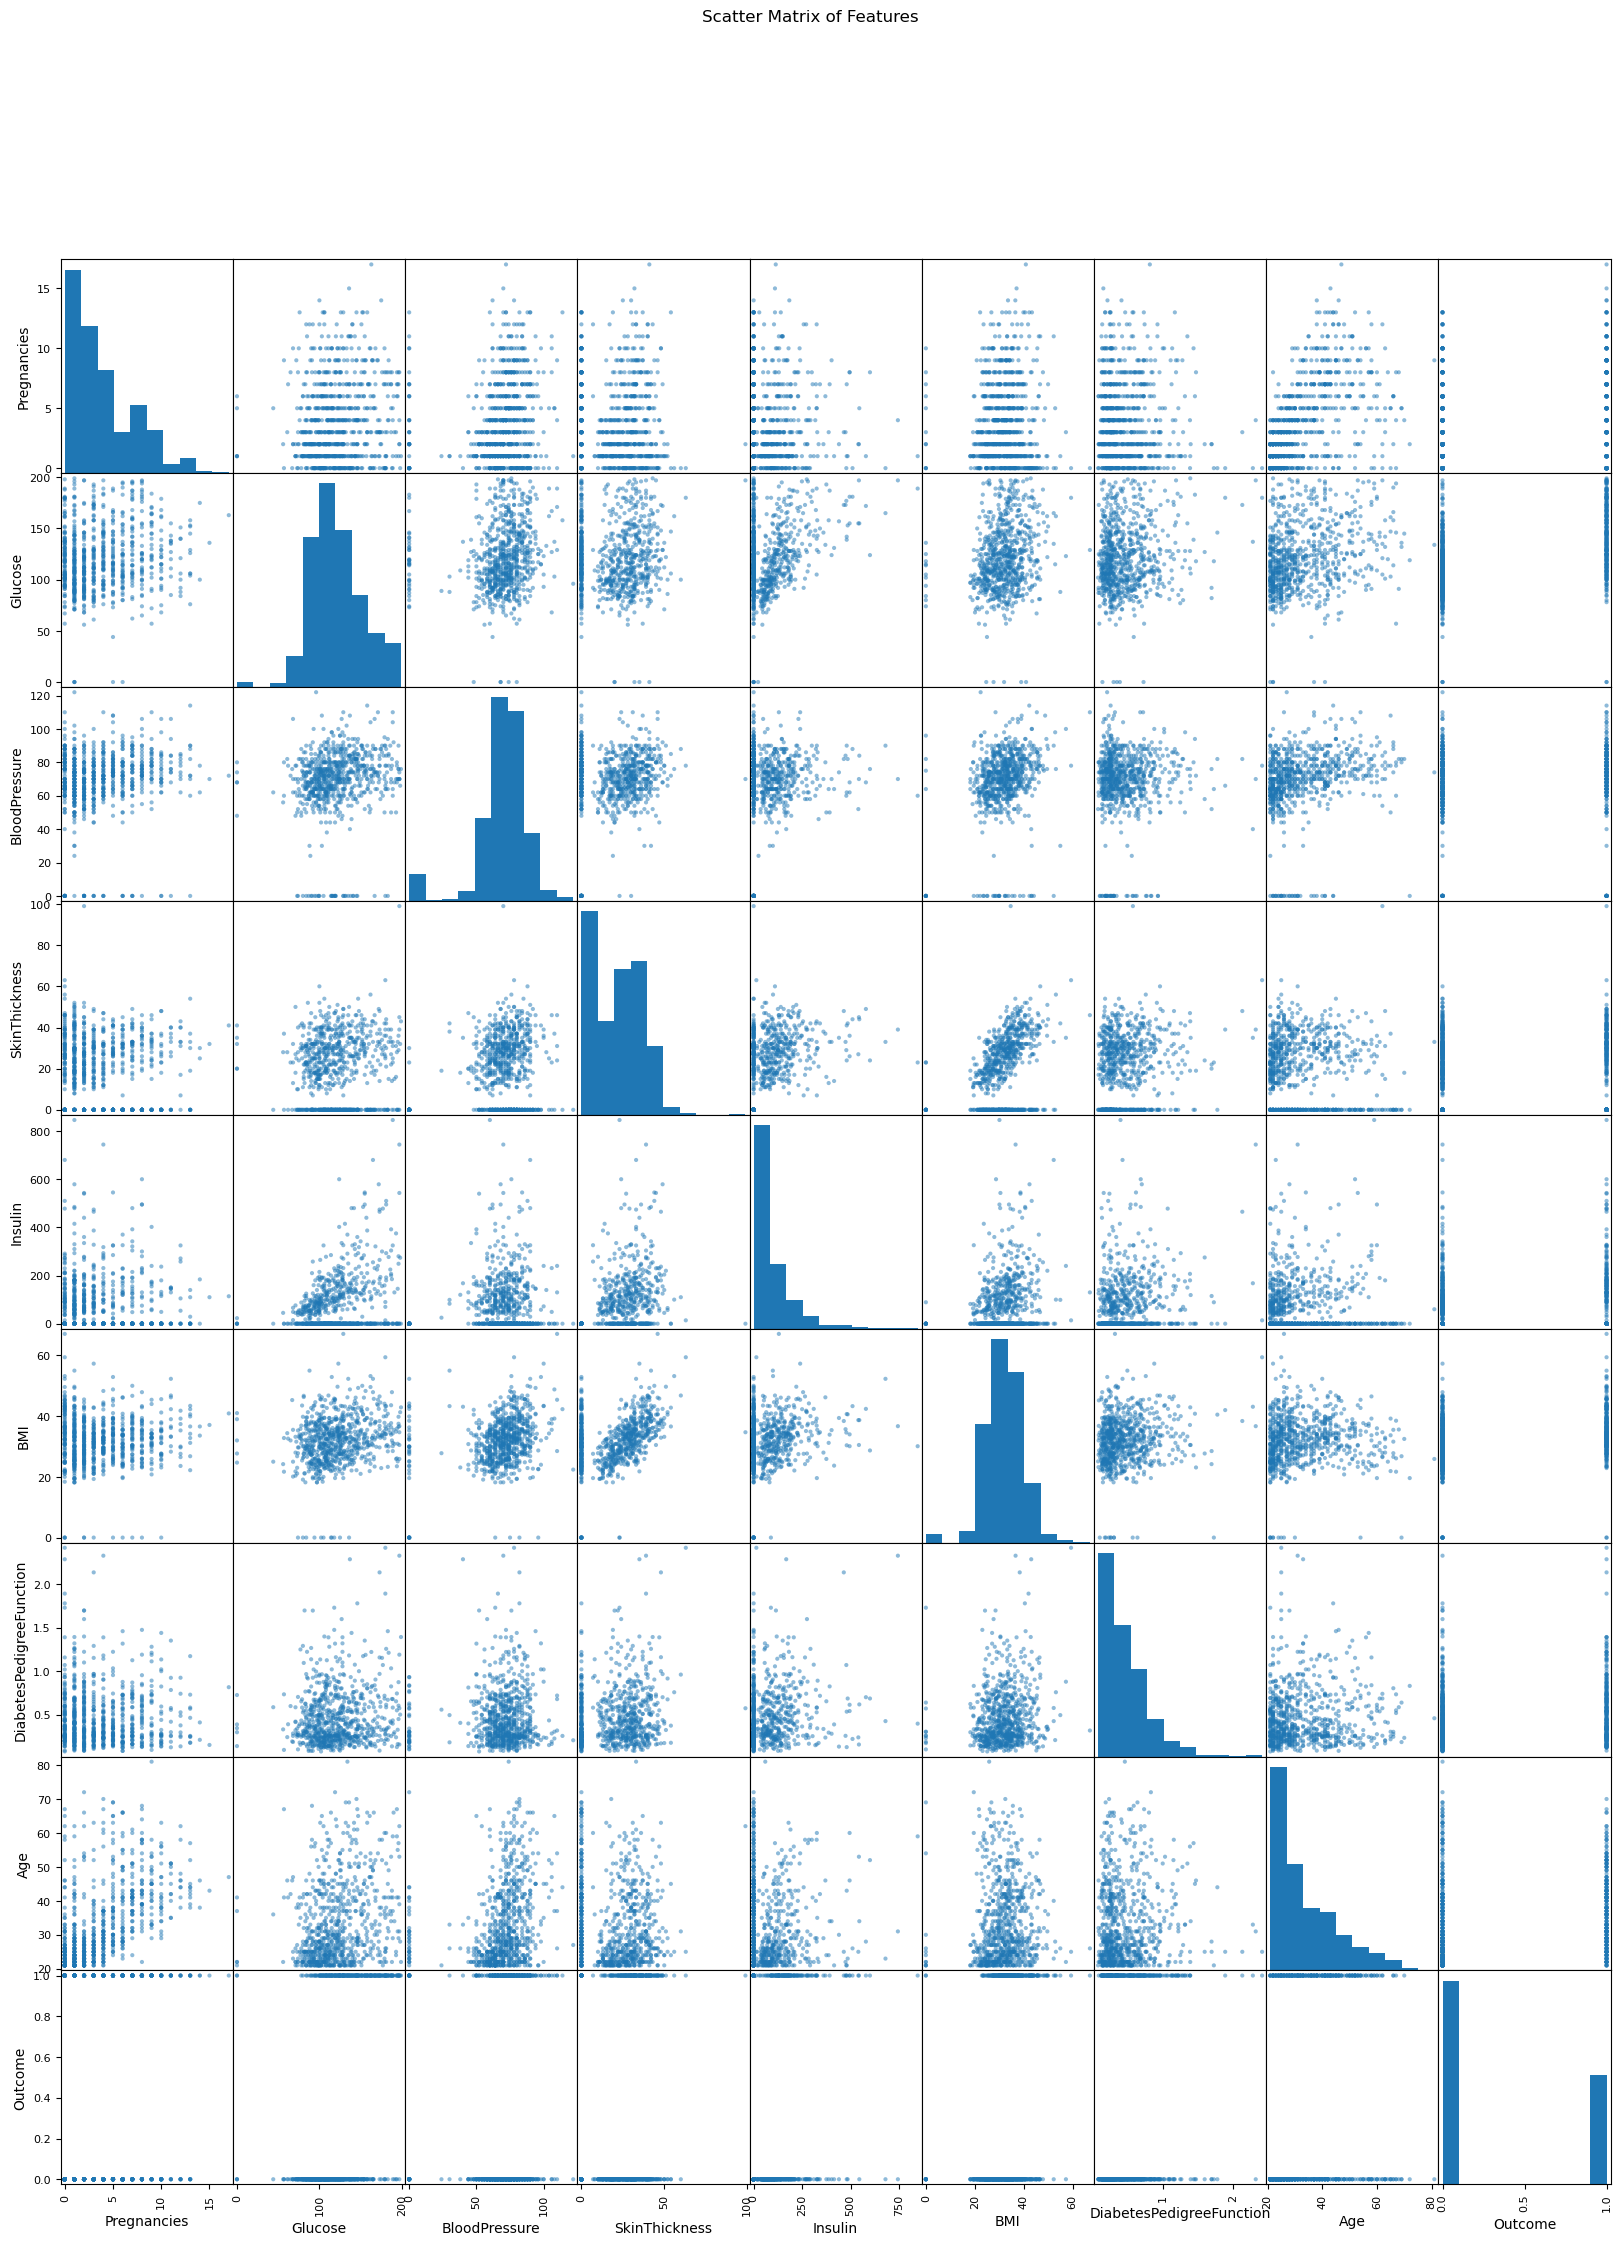

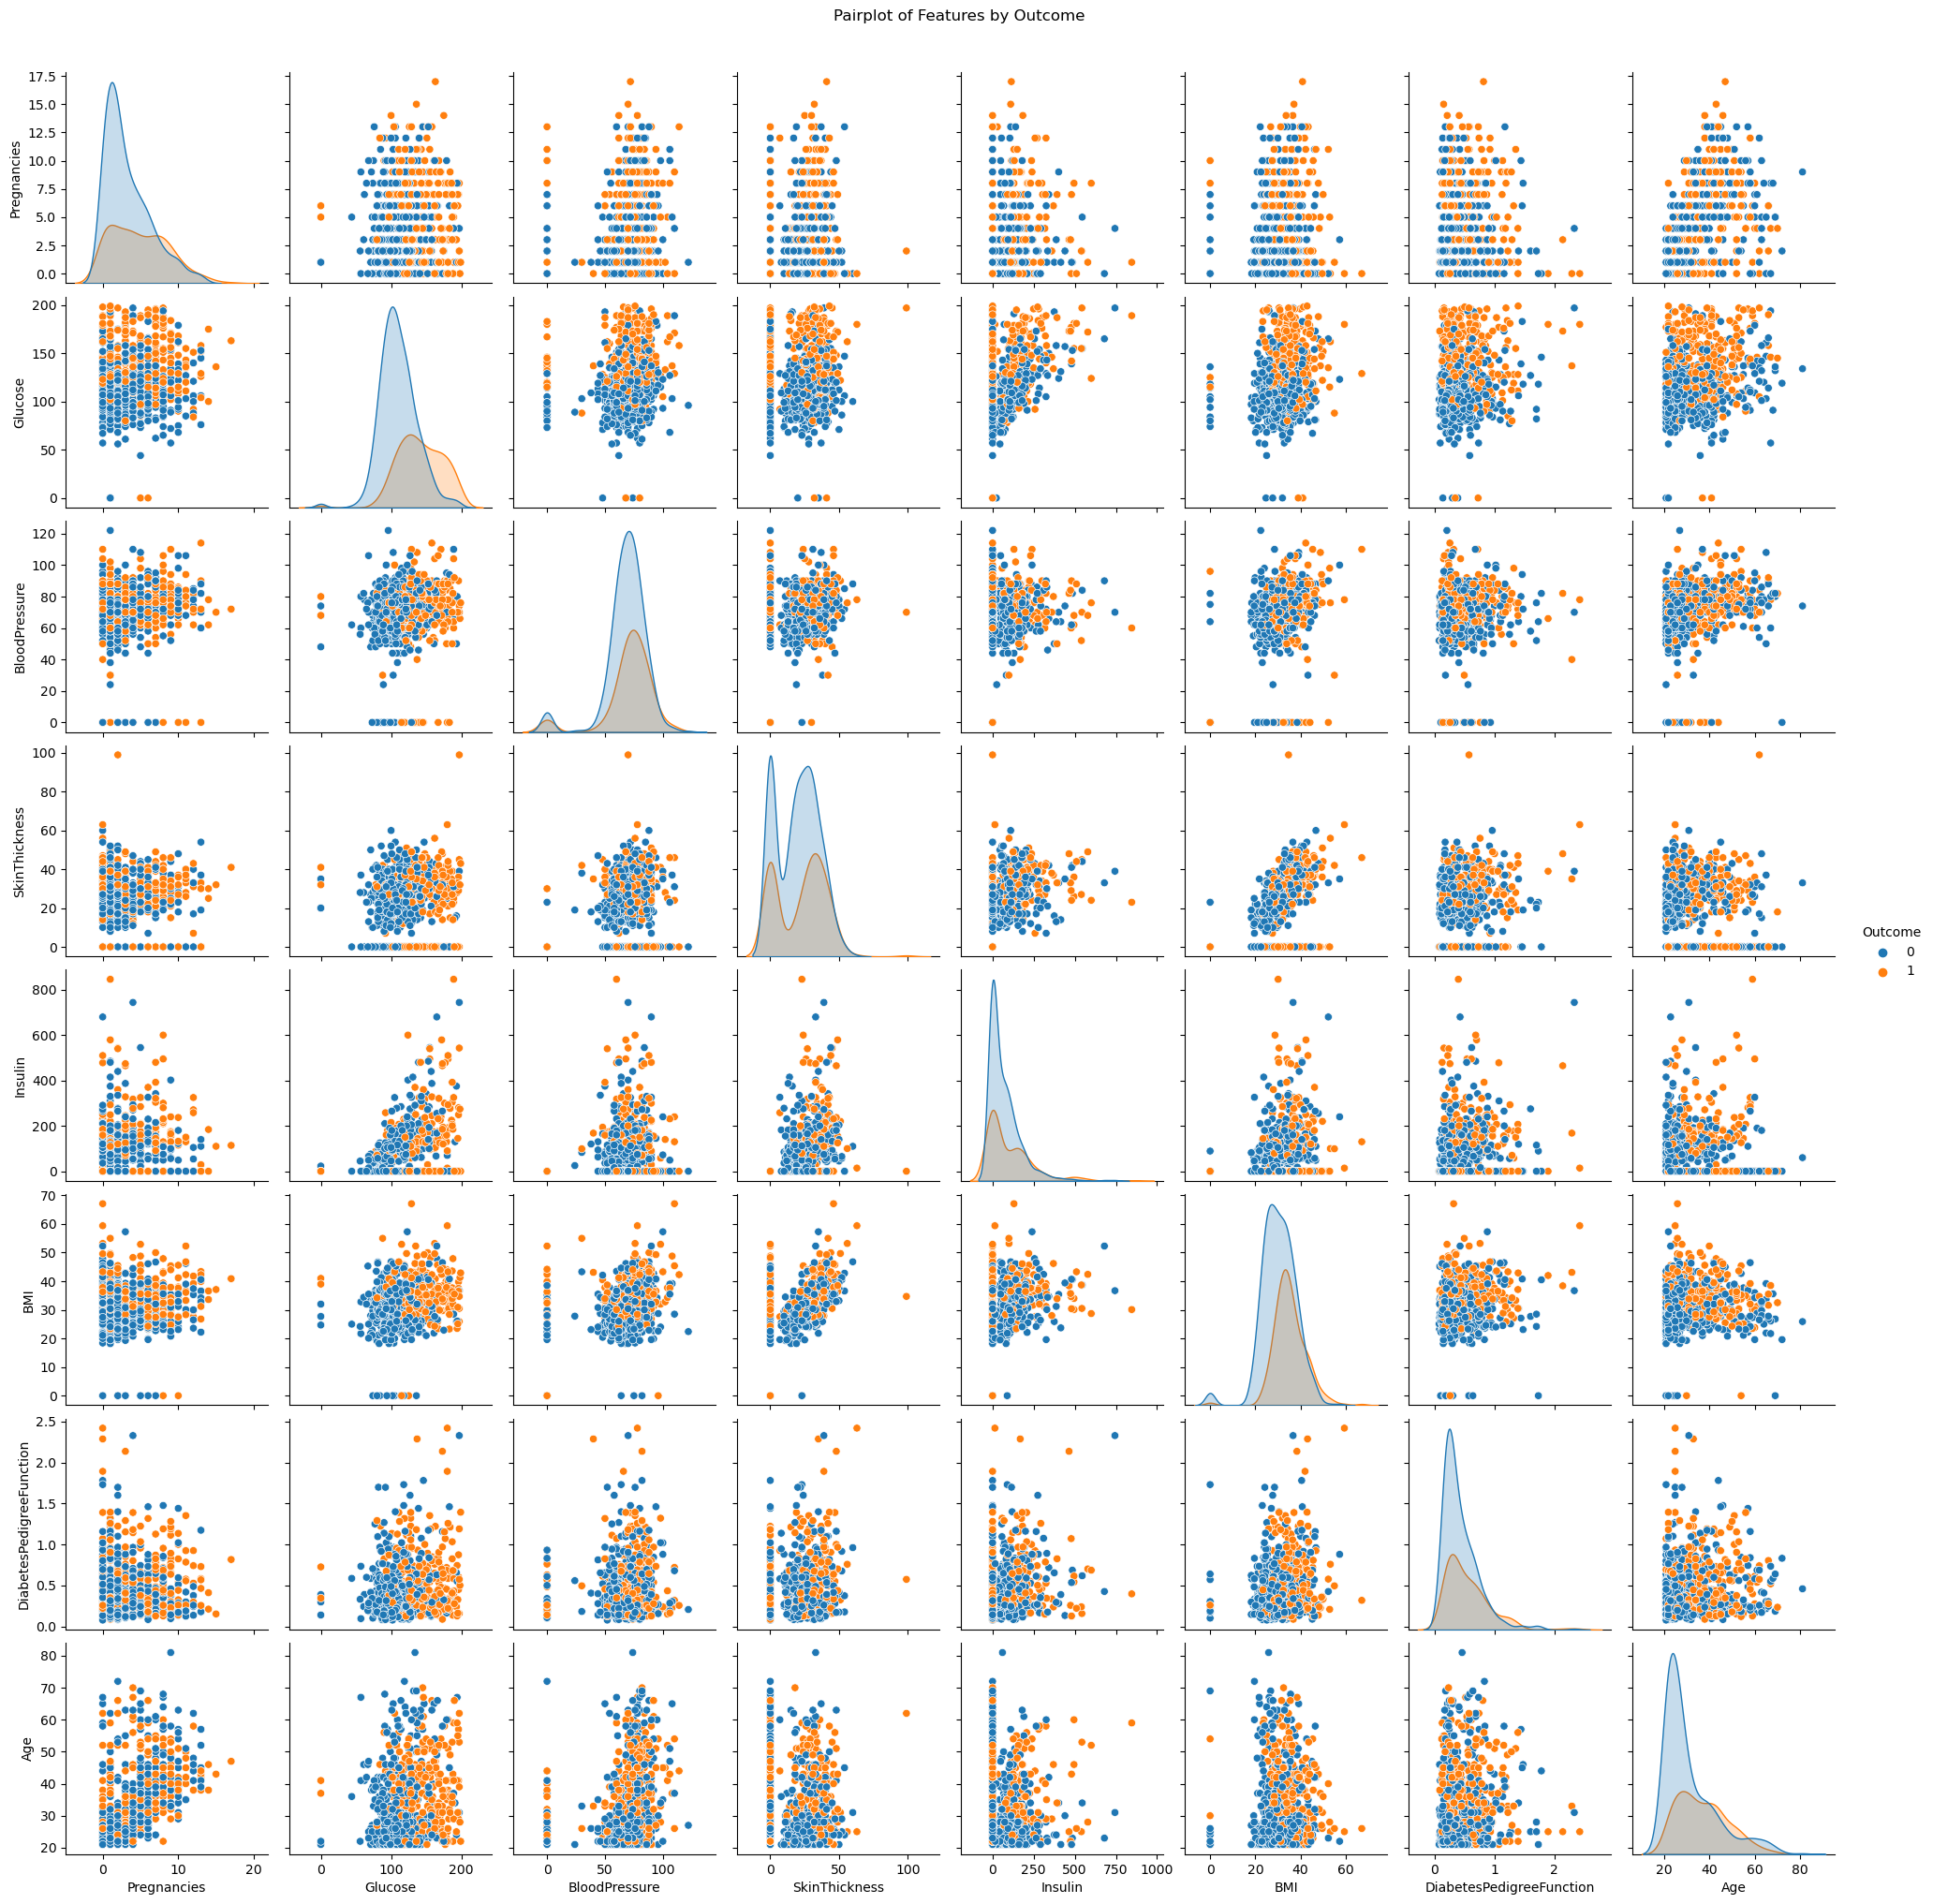

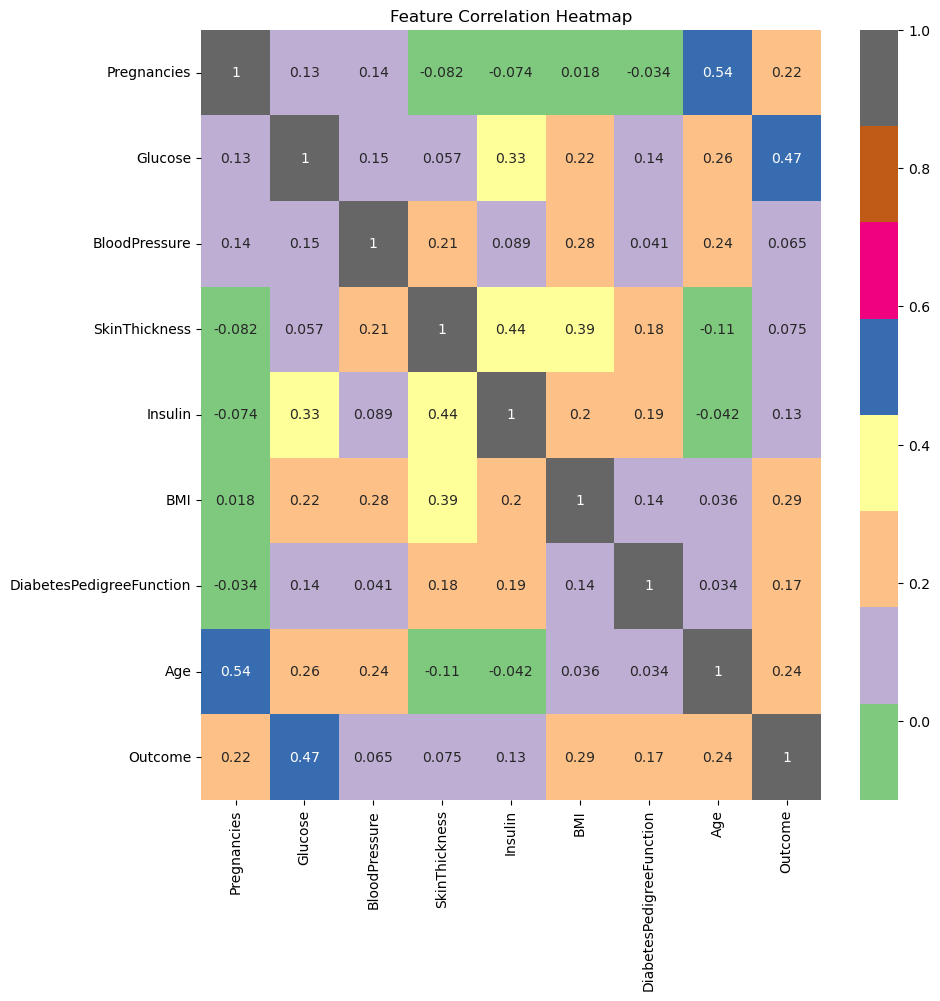


Train/Test split shapes:
X_train: (614, 8), y_train: (614,)
X_test: (154, 8), y_test: (154,)
Missing values in X: 0
Missing values in y: 0


C:\Users\Anshika\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\Anshika\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `kee

C:\Users\Anshika\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\Anshika\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `kee


Max training accuracy: 100.00% at k = [1]


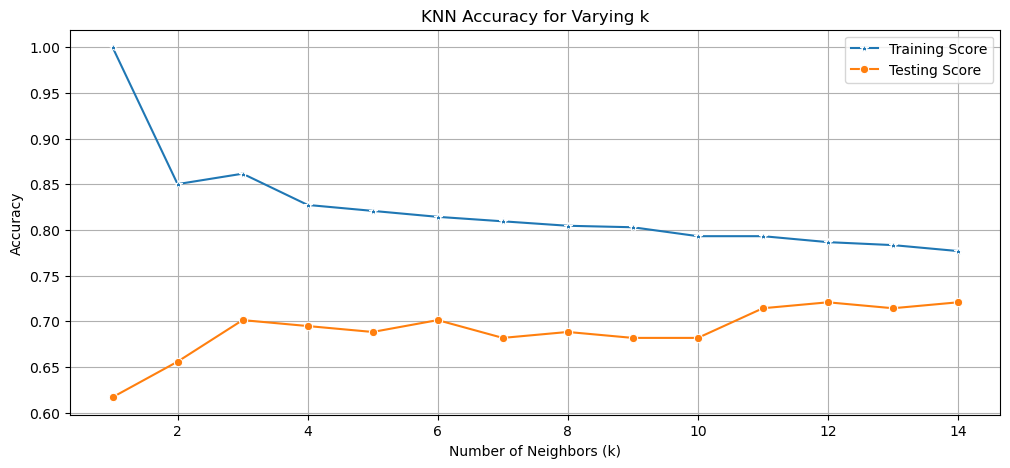


Final Model Evaluation (k=11):
Accuracy: 71.43%
Confusion Matrix:
[[78 21]
 [23 32]]
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.79      0.78        99
           1       0.60      0.58      0.59        55

    accuracy                           0.71       154
   macro avg       0.69      0.68      0.69       154
weighted avg       0.71      0.71      0.71       154



C:\Users\Anshika\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load the dataset
proj_data = pd.read_csv('diabetes-data.csv')
print("First 5 rows of dataset:")
print(proj_data.head())

# Basic info about the dataset
print("\nDataset Info:")
proj_data.info()

# Descriptive statistics
print("\nDescriptive Statistics:")
print(proj_data.describe().T)

# Copy the data to handle missing values
proj_data_copy = proj_data.copy()

# Check for missing values
print("\nMissing values before handling:")
print(proj_data_copy.isnull().sum())

# Plot initial histograms
proj_data_copy.hist(figsize=(20, 20))
plt.suptitle("Histograms Before Filling Missing Values")
plt.show()

# Fill missing values with mean
cols_to_fill = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_to_fill:
    proj_data_copy[col].fillna(proj_data_copy[col].mean(), inplace=True)

# Plot histograms after filling missing values
proj_data_copy.hist(figsize=(20, 20))
plt.suptitle("Histograms After Filling Missing Values")
plt.show()

# Check class distribution
print("\nOutcome Class Distribution:")
print(proj_data_copy['Outcome'].value_counts())
proj_data_copy['Outcome'].value_counts().plot(kind='bar')
plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

# Scatter matrix plot
scatter_matrix(proj_data_copy, figsize=(20, 25))
plt.suptitle("Scatter Matrix of Features")
plt.show()

# Pair plot colored by Outcome
sns.pairplot(proj_data_copy, hue='Outcome')
plt.suptitle("Pairplot of Features by Outcome", y=1.02)
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(proj_data_copy.corr(), annot=True, cmap='Accent')
plt.title("Feature Correlation Heatmap")
plt.show()

# Feature scaling
scale_X = StandardScaler()
X = scale_X.fit_transform(proj_data_copy.drop("Outcome", axis=1))
X = pd.DataFrame(X, columns=proj_data_copy.drop("Outcome", axis=1).columns)

# Target variable
y = proj_data_copy["Outcome"].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTrain/Test split shapes:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

# Check for any remaining missing values
print(f"Missing values in X: {X.isnull().sum().sum()}")
print(f"Missing values in y: {pd.Series(y).isnull().sum()}")

# KNN classifier training and accuracy testing
training_score = []
testing_score = []

for i in range(1, 15):
    knn = KNeighborsClassifier(i)
    knn.fit(X_train, y_train)
    training_score.append(knn.score(X_train, y_train))
    testing_score.append(knn.score(X_test, y_test))

max_training_score = max(training_score)
best_k = [i + 1 for i, score in enumerate(training_score) if score == max_training_score]

print(f'\nMax training accuracy: {max_training_score*100:.2f}% at k = {best_k}')

# Plot training and testing scores
plt.figure(figsize=(12, 5))
sns.lineplot(x=range(1, 15), y=training_score, marker='*', label='Training Score')
sns.lineplot(x=range(1, 15), y=testing_score, marker='o', label='Testing Score')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy for Varying k')
plt.legend()
plt.grid(True)
plt.show()

# Final model with best performing k (example: k=11)
knn_final = KNeighborsClassifier(11)
knn_final.fit(X_train, y_train)
y_pred = knn_final.predict(X_test)

# Final Evaluation
print("\nFinal Model Evaluation (k=11):")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))
